In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional
import json
import os,sys
sys.path.append("/home/mnurisso/miller_npl/generalization_transformer_marc/src")

import matplotlib.pyplot as plt

# Import necessary modules and classes
from MillerDataGen import MillerDataGenerator, DataGeneratorConfig
#from MillerDataVis import MillerVisualizer, VisualizationConfig
from MillerTest import MillerTestConfig, create_model
from MillerTrainer import MillerTrainer, TrainerConfig
#from utils import ExperimentLogger, ConfigManager, ResultAggregator, create_default_config

In [3]:
BATCH_SIZE = 128
N_INPUTS = 30
FEATURE_DIM = 10
SEQUENCE_LEN = 8
SAVE = False

In [ ]:
s

In [24]:
tconf = TrainerConfig()
tconf.losses = ["reconstruction","similarity"]
tconf.num_inputs = genconf.num_inputs
tconf.batch_size = BATCH_SIZE
tconf.num_epochs: int = 1000
tconf.learning_rate: float = 5*1e-4
tconf.weight_decay: float = 1e-5
tconf.patience = 100
tconf.min_lr = 0

In [25]:
histories = []
embs = []
sim_vals = np.linspace(0.2,.4,2)

for lambda_sim in sim_vals:
    model = create_model(model_config, "softmax")
    torch.nn.init.uniform_(model.embed.weight, a = 0*model_config.init_scale,b = model_config.init_scale)

    tconf.lambda_rec = (1 - lambda_sim/np.max(sim_vals))
    tconf.lambda_sim = (lambda_sim)
    trainer = MillerTrainer(model, gen, tconf)

    history = trainer.train(shutupfor = 100)
    histories.append(history)

    x, __ = model(torch.eye(N_INPUTS).to("cuda").unsqueeze(0))
    x = x[0,:,:].detach().cpu().numpy()
    embs.append(x)

Epoch 0:
  Train - Sim Loss: 0.3931, Reconstruction Loss: 61.1886
  Val - G Score: 0.1431, I Score: 0.1773
Epoch 100:
  Train - Sim Loss: 0.4299, Reconstruction Loss: 6.4738
  Val - G Score: 0.1433, I Score: 0.2538
Epoch 200:
  Train - Sim Loss: 0.4571, Reconstruction Loss: 1.3892
  Val - G Score: 0.1503, I Score: 0.3275
Epoch 300:
  Train - Sim Loss: 0.4092, Reconstruction Loss: 0.3921
  Val - G Score: 0.1778, I Score: 0.3885
Epoch 400:
  Train - Sim Loss: 0.3155, Reconstruction Loss: 0.1218
  Val - G Score: 0.2671, I Score: 0.4649
Epoch 500:
  Train - Sim Loss: 0.2069, Reconstruction Loss: 0.0459
  Val - G Score: 0.4664, I Score: 0.5529
Epoch 600:
  Train - Sim Loss: 0.1399, Reconstruction Loss: 0.0288
  Val - G Score: 0.6139, I Score: 0.6057
Epoch 700:
  Train - Sim Loss: 0.1184, Reconstruction Loss: 0.0247
  Val - G Score: 0.6337, I Score: 0.6221
Epoch 800:
  Train - Sim Loss: 0.1041, Reconstruction Loss: 0.0227
  Val - G Score: 0.6606, I Score: 0.6308
Epoch 900:
  Train - Sim Loss

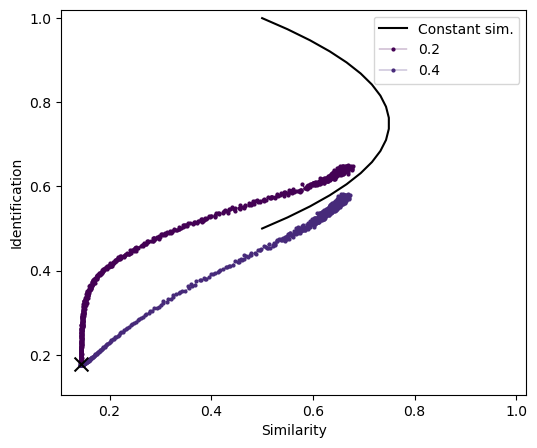

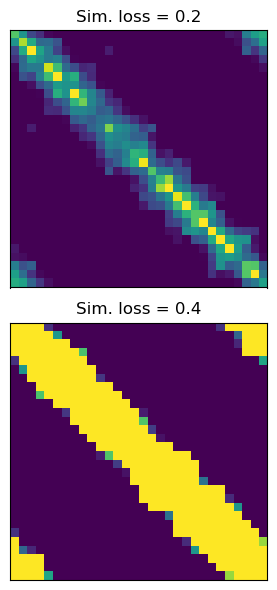

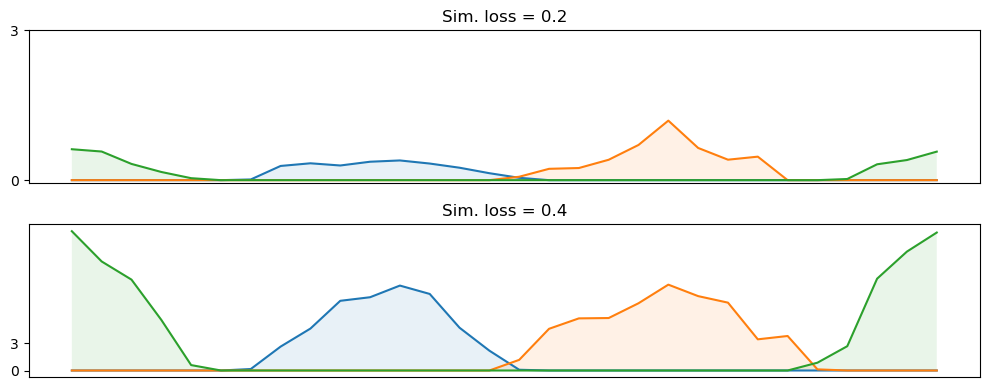

In [26]:
savepath = "/home/mnurisso/miller_npl/figures/"
tspace = np.linspace(0,1,20)
f = plt.figure(figsize = (6,5))
plt.plot(1/2 + tspace - tspace**2, 1 - tspace/2,color = "k")


for i in range(len(histories)):
    plt.plot(histories[i]['similarity_scores'],
        histories[i]['identification_scores'], 
        '-o', markersize = 2, linewidth = 0.3, alpha = 1, color = plt.cm.viridis(30*i))

plt.scatter([histories[0]['similarity_scores'][0]],[histories[0]['identification_scores'][0]],color = "k", s = 100, zorder = 30, marker = "x")

plt.xlim([1/SEQUENCE_LEN-0.02,1.02])
plt.ylim([1/SEQUENCE_LEN-0.02,1.02])
plt.xlabel("Similarity")
plt.ylabel("Identification")
plt.legend(["Constant sim."]+ [f"{s}" for s in np.round(sim_vals,2)])

if SAVE:
    plt.savefig(savepath+f"learning_curves_feats{N_INPUTS}_hidden{FEATURE_DIM}.pdf", bbox_inches = "tight")

f = plt.figure(figsize = (10,6))
for i in range(len(histories)):
    ax = plt.subplot(2,len(histories)//2+(0 if len(histories)%2 == 0 else 1),i+1)
    ax.imshow(np.maximum(0,embs[i]@embs[i].T), vmin = 0, vmax = 1)
    ax.set_title(f"Sim. loss = {np.round(sim_vals[i],2)}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

if SAVE:
    plt.savefig(savepath+f"repsimilarities_feats{N_INPUTS}_hidden{FEATURE_DIM}.pdf", bbox_inches = "tight")

f = plt.figure(figsize = (10,4))
xx = np.linspace(0,1,N_INPUTS)
for i in range(len(histories)):
    S = np.maximum(0,embs[i]@embs[i].T)
    ax = plt.subplot(2,len(histories)//2+(0 if len(histories)%2 == 0 else 1),i+1)
    ax.plot(xx,S[10,:])
    ax.fill_between(xx,0,S[10,:], alpha = 0.1)
    ax.plot(xx,S[20,:])
    ax.fill_between(xx,0,S[20,:], alpha = 0.1)
    ax.plot(xx,S[29,:])
    ax.fill_between(xx,0,S[29,:], alpha = 0.1)
    ax.set_title(f"Sim. loss = {np.round(sim_vals[i],2)}")
    #ax.set_ylim([0,3])
    ax.set_xticks([])
    ax.set_yticks([0,3])
plt.tight_layout()

if SAVE:
    plt.savefig(savepath+f"resolutions_feats{N_INPUTS}_hidden{FEATURE_DIM}.pdf", bbox_inches = "tight")

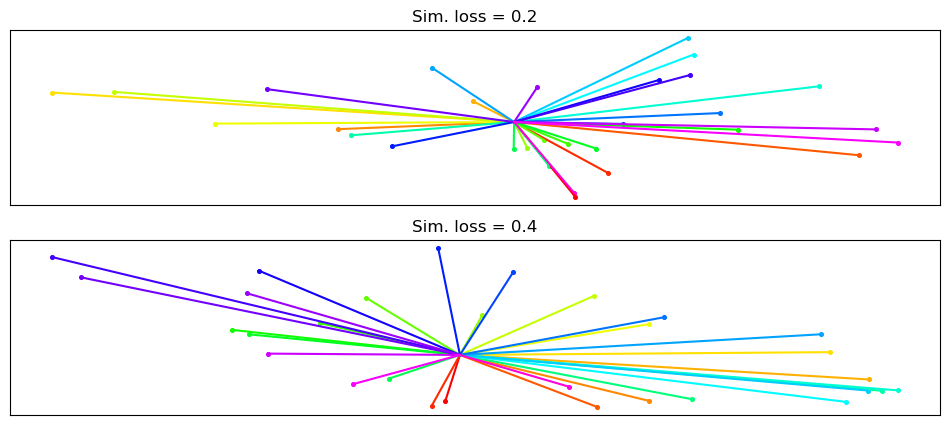

In [27]:
f = plt.figure(figsize = (12,5))

for i in range(len(histories)):
    ax = plt.subplot(2,len(histories)//2+(0 if len(histories)%2 == 0 else 1),i+1)
    for n in range(N_INPUTS):
        ax.plot([0,embs[i][n,0]],[0,embs[i][n,1]], color = plt.cm.hsv(0.03*n) )
        ax.scatter([embs[i][n,0]],[embs[i][n,1]], color = plt.cm.hsv(0.03*n), s = 7 )

    ax.set_title(f"Sim. loss = {np.round(sim_vals[i],2)}")
    #ax.set_ylim([-0.65,0.655])
    ax.set_xticks([])
    ax.set_yticks([])

#plt.savefig(savepath+f"features_feats{N_INPUTS}_hidden{FEATURE_DIM}.pdf", bbox_inches = "tight")


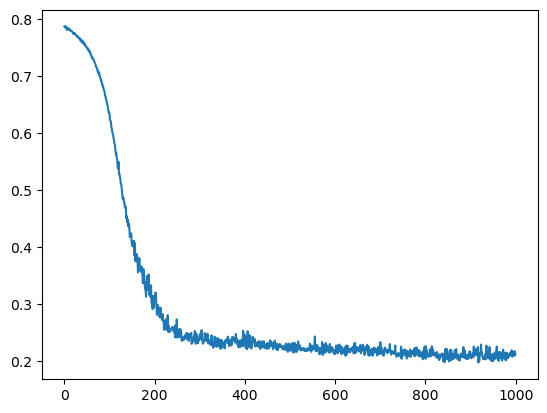

In [28]:
plt.plot(histories[-1]["similarity_losses"])

## Single one

In [29]:
model_config = MillerTestConfig(
            feature_dim=FEATURE_DIM,
            mlp_dim =10,
            input_dim=genconf.num_inputs,
            sequence_len=genconf.sequence_len,
            init_scale = 2
        )

tconf = TrainerConfig()
tconf.losses = ["reconstruction","similarity"]
tconf.num_inputs = genconf.num_inputs
tconf.batch_size = BATCH_SIZE
tconf.num_epochs: int = 300
tconf.learning_rate: float = 5*1e-3
tconf.weight_decay: float = 1e-3*0
tconf.patience = 100
tconf.min_lr = 0

In [30]:
model = create_model(model_config, "softmax")
torch.nn.init.uniform_(model.embed.weight, a = 0*model_config.init_scale,b = model_config.init_scale)

tconf.lambda_rec = 0
tconf.lambda_sim = .1
trainer = MillerTrainer(model, gen, tconf)

history,embs = trainer.train(shutupfor = 10,compute_embeddings=True)


Epoch 0:
  Train - Sim Loss: 0.1954, Reconstruction Loss: 0.0000
  Val - G Score: 0.1450, I Score: 0.1820
Epoch 10:
  Train - Sim Loss: 0.1426, Reconstruction Loss: 0.0000
  Val - G Score: 0.2680, I Score: 0.2948
Epoch 20:
  Train - Sim Loss: 0.0713, Reconstruction Loss: 0.0000
  Val - G Score: 0.5613, I Score: 0.4909
Epoch 30:
  Train - Sim Loss: 0.0573, Reconstruction Loss: 0.0000
  Val - G Score: 0.6365, I Score: 0.5456
Epoch 40:
  Train - Sim Loss: 0.0573, Reconstruction Loss: 0.0000
  Val - G Score: 0.6681, I Score: 0.5801
Epoch 50:
  Train - Sim Loss: 0.0526, Reconstruction Loss: 0.0000
  Val - G Score: 0.6700, I Score: 0.5938
Epoch 60:
  Train - Sim Loss: 0.0523, Reconstruction Loss: 0.0000
  Val - G Score: 0.6766, I Score: 0.5984
Epoch 70:
  Train - Sim Loss: 0.0555, Reconstruction Loss: 0.0000
  Val - G Score: 0.6886, I Score: 0.6046
Epoch 80:
  Train - Sim Loss: 0.0524, Reconstruction Loss: 0.0000
  Val - G Score: 0.6825, I Score: 0.6097
Epoch 90:
  Train - Sim Loss: 0.0551, 

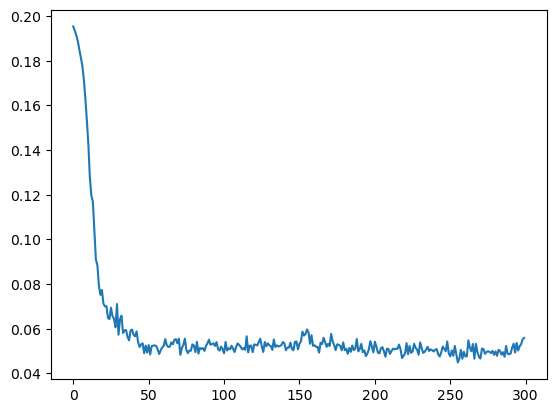

In [31]:
plt.plot(history["similarity_losses"])

/tmp/ipykernel_321946/350644062.py:9: RuntimeWarning: divide by zero encountered in divide
  sas = -8/(12*(a/tspace)**2)*(np.pi**2 + 6*a*np.log(2) + 12*ses)


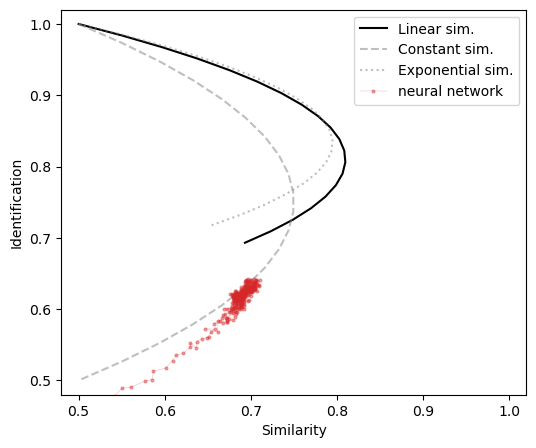

In [32]:
from mpmath import polylog


tspace = np.linspace(0,1,20)
f = plt.figure(figsize = (6,5))

a = 4
ses = np.array([polylog(2,-np.exp(a/2)) for t in tspace])
sas = -8/(12*(a/tspace)**2)*(np.pi**2 + 6*a*np.log(2) + 12*ses)

plt.plot(1/2 + tspace - (3/2 - np.log(2))*tspace**2, 1 - (1-np.log(2))*tspace,color = "k", label = "Linear sim.")
plt.plot(1/2 + tspace - tspace**2, 1 - tspace/2,color = "grey", alpha = 0.5, linestyle = "--", label = "Constant sim.")
plt.plot(1/2 + tspace - 3/2*tspace**2 + sas, 1 - tspace + (2*tspace/a)*np.log(1/2*(1 + np.exp(a/2))),
                        color = "grey", alpha = 0.5, linestyle = ":", label = "Exponential sim.")


plt.plot(history['similarity_scores'],
        history['identification_scores'], 
        '-o', markersize = 2, linewidth = 0.3, alpha = .4, 
        color = "tab:red", label = "neural network")

#plt.scatter([histories[0]['similarity_scores'][0]],[histories[0]['identification_scores'][0]],color = "k", s = 100, zorder = 30, marker = "x")

plt.xlim([0.48,1.02])
plt.ylim([0.48,1.02])
plt.xlabel("Similarity")
plt.ylabel("Identification")
plt.legend()

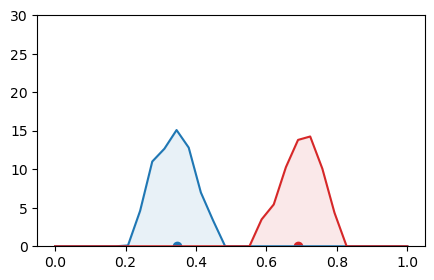

In [33]:
import matplotlib.animation as animation

sas = [10,20]
cols = ["tab:blue","tab:red"]
xx = np.linspace(0,1,N_INPUTS)

f,ax = plt.subplots(1,1,figsize = (5,3))
ax.set_ylim([0,30])

S = np.maximum(0,embs[0]@embs[0].T)
for i,s in enumerate(sas):
    ax.plot(xx,S[s,:],color = cols[i])
    ax.fill_between(xx,0,S[s,:], alpha = 0.1,color = cols[i])
    ax.scatter([xx[s]],[0],color = cols[i])

def animate(i):
    plt.cla()
    S = np.maximum(0,embs[3*i]@embs[3*i].T)
    for k,s in enumerate(sas):
        ax.plot(xx,S[s,:],color = cols[k])
        ax.fill_between(xx,0,S[s,:], alpha = 0.1,color = cols[k])
        ax.scatter([xx[s]],[0],color = cols[k])
    ax.set_ylim([0,30])




ani = animation.FuncAnimation(f, animate, repeat=False, frames=99, interval=50)

# To save the animation using Pillow as a gif
writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save('scatter.gif', writer=writer)

plt.show()
